# Task 7: Text Summarization Using Pre-trained Models

## 1. Install Libraries

Uses `%pip` instead of `!pip` so the packages install into the kernel's actual environment (avoids `ModuleNotFoundError` from a mismatched install).

In [1]:
%pip install -q transformers datasets torch sentencepiece accelerate \
    rouge-score pandas numpy sumy gensim nltk tqdm

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 71.1 MB/s eta 0:00:00


## 2. Importing Libraries

In [2]:
import importlib
import subprocess
import sys

REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'torch': 'torch',
    'matplotlib': 'matplotlib',
    'datasets': 'datasets',
    'transformers': 'transformers',
    'rouge_score': 'rouge-score',
    'sentencepiece': 'sentencepiece',
}

def ensure_installed(import_name, pip_name):
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f'Installing missing package: {pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for import_name, pip_name in REQUIRED.items():
    ensure_installed(import_name, pip_name)

import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

pd.set_option('display.max_colwidth', 200)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 3. Load the CNN/DailyMail Dataset

Loaded as `abisee/cnn_dailymail` (full `namespace/name` form required by Hugging Face) — the same data recommended on Kaggle.

In [3]:
cnn_dailymail = load_dataset('abisee/cnn_dailymail', '3.0.0')
cnn_dailymail

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

3.0.0/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

3.0.0/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

In [4]:
test_data = cnn_dailymail['test']
print("Number of test examples:", len(test_data))
test_data[0]

Number of test examples: 11490


{'article': '(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC\'s founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians\' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking at Wednesday

## 4. Preprocess and Sample the Data

In [5]:
def clean_text(text):
    text = re.sub(r'\(CNN\)\s*--?\s*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

SAMPLE_SIZE = 50

df = test_data.to_pandas()[['article', 'highlights']]
df['article'] = df['article'].apply(clean_text)
df['highlights'] = df['highlights'].apply(clean_text)
df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
df.head(3)

,article,highlights
0,"Down Augusta way they say the azaleas are in full bloom, which is more than can be said for England’s Justin Rose. A bruising Florida swing last month saw the Englishman fall outside the world’s t...",Justin Rose bounced back from Florida misery by carding 69 in Houston . Three-time Masters champion Phil Mickelson enjoyed return to form . Paul Casey celebrated last-gasp Masters invitation with ...
1,"There was no special treatment for Lewis Ferguson at Paul Nicholls’ yard on Thursday morning. The 18-year-old was mucking out the stables as usual, just a cut on the nose to show for the fall whic...",Lewis Ferguson fell from Merrion Square at Wincanton on Wednesday . Despite spectacular tumble he escaped with just a cut nose . Ferguson has been mucking out stables as usual on Thursday morning ...
2,"When emergency crews received a call saying 'someone' had been knocked down by a car in Essex, they immediately sent two ambulances to the rescue. But the vehicles returned to base just moments la...","Woman reported 'someone' had been run over, but victim was a squirrel . Another man dialled 999 to say he dropped a burger which was 'bleeding' East of England ambulance service warned hoax calls ..."


## 5. Inspect a Sample

In [6]:
sample = df.iloc[0]
print("Article:\n", sample['article'][:500], "...")
print("\nReference Summary:\n", sample['highlights'])

Article:
 Down Augusta way they say the azaleas are in full bloom, which is more than can be said for England’s Justin Rose. A bruising Florida swing last month saw the Englishman fall outside the world’s top 10. For a player who has been virtually a fixture in the top five for the last three years it was certainly a dent to the ego, with the Masters now just around the corner. Rose’s solution to his miserable form — three missed cuts and a 55th-place finish at the Cadillac Championship in four PGA Tour s ...

Reference Summary:
 Justin Rose bounced back from Florida misery by carding 69 in Houston . Three-time Masters champion Phil Mickelson enjoyed return to form . Paul Casey celebrated last-gasp Masters invitation with fine round of 68 .


## 6. Load a Pre-trained Summarization Model

In [7]:
MODEL_NAME = 'facebook/bart-large-cnn'  # alternatives: 't5-small', 'google/pegasus-cnn_dailymail'
MAX_INPUT_TOKENS = 1024
MAX_SUMMARY_LENGTH = 128
MIN_SUMMARY_LENGTH = 30

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

## 7. Generate Abstractive Summaries

In [8]:
def summarize_batch(texts, batch_size=8):
    summaries = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        inputs = tokenizer(
            batch, max_length=MAX_INPUT_TOKENS, truncation=True,
            padding=True, return_tensors='pt',
        ).to(device)

        with torch.no_grad():
            summary_ids = model.generate(
                **inputs,
                max_length=MAX_SUMMARY_LENGTH,
                min_length=MIN_SUMMARY_LENGTH,
                num_beams=4,
                length_penalty=2.0,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )
        summaries.extend(
            tokenizer.decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
            for ids in summary_ids
        )
        print(f'  processed {min(start + batch_size, len(texts))}/{len(texts)}')
    return summaries

df['generated_summary'] = summarize_batch(df['article'].tolist())
df[['highlights', 'generated_summary']].head(3)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  processed 8/50
  processed 16/50
  processed 24/50
  processed 32/50
  processed 40/50
  processed 48/50
  processed 50/50


,highlights,generated_summary
0,Justin Rose bounced back from Florida misery by carding 69 in Houston . Three-time Masters champion Phil Mickelson enjoyed return to form . Paul Casey celebrated last-gasp Masters invitation with ...,Justin Rose hit 17 out of 18 greens in regulation and signed for a 69 at the Shell Houston Open on Thursday. The Englishman fell outside the world’s top 10 after a bruising Florida swing last mont...
1,Lewis Ferguson fell from Merrion Square at Wincanton on Wednesday . Despite spectacular tumble he escaped with just a cut nose . Ferguson has been mucking out stables as usual on Thursday morning ...,Lewis Ferguson survived a spectacular fall from Merrion Square. The 18-year-old was mucking out the stables as usual at Paul Nicholls’ yard on Thursday morning. Ferguson escaped the fall and the o...
2,"Woman reported 'someone' had been run over, but victim was a squirrel . Another man dialled 999 to say he dropped a burger which was 'bleeding' East of England ambulance service warned hoax calls ...",Two ambulances sent to Epping Forest after 'someone' was run down. But the 'victim' turned out to be a squirrel that had been run over by a car. East of England ambulance service released a list o...


## 8. Evaluate Summaries with ROUGE

In [9]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge_rows = []
for _, row in df.iterrows():
    scores = scorer.score(row['highlights'], row['generated_summary'])
    rouge_rows.append({
        'rouge1_f': scores['rouge1'].fmeasure,
        'rouge2_f': scores['rouge2'].fmeasure,
        'rougeL_f': scores['rougeL'].fmeasure,
    })

rouge_df = pd.DataFrame(rouge_rows)
print("Average ROUGE-1 F1:", round(rouge_df['rouge1_f'].mean(), 4))
print("Average ROUGE-2 F1:", round(rouge_df['rouge2_f'].mean(), 4))
print("Average ROUGE-L F1:", round(rouge_df['rougeL_f'].mean(), 4))
rouge_df.describe()

Average ROUGE-1 F1: 0.4431
Average ROUGE-2 F1: 0.2326
Average ROUGE-L F1: 0.3204


,rouge1_f,rouge2_f,rougeL_f
count,50.000000,50.000000,50.000000
mean,0.443060,0.232634,0.320375
std,0.152865,0.171454,0.146586
min,0.168421,0.021505,0.105263
25%,0.347212,0.126097,0.228871
50%,0.434816,0.208900,0.285394
75%,0.541188,0.281981,0.388362
max,0.872727,0.846154,0.867925


## 9. Bonus: Extractive Summarization with TextRank

In [10]:
ensure_installed('sumy', 'sumy')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

LANGUAGE = 'english'
SENTENCES_COUNT = 3
stemmer = Stemmer(LANGUAGE)
textrank = TextRankSummarizer(stemmer)
textrank.stop_words = get_stop_words(LANGUAGE)

def summarize_extractive(text):
    parser = PlaintextParser.from_string(text, Tokenizer(LANGUAGE))
    sentences = textrank(parser.document, SENTENCES_COUNT)
    return ' '.join(str(s) for s in sentences)

df['extractive_summary'] = df['article'].apply(summarize_extractive)
df[['highlights', 'extractive_summary']].head(3)

,highlights,extractive_summary
0,Justin Rose bounced back from Florida misery by carding 69 in Houston . Three-time Masters champion Phil Mickelson enjoyed return to form . Paul Casey celebrated last-gasp Masters invitation with ...,"On a day when American Scott Piercy went round in 63 and Phil Mickelson enjoyed his best round in months with a 66, it was hardly surprising the only reporter waiting to talk to Rose was this one...."
1,Lewis Ferguson fell from Merrion Square at Wincanton on Wednesday . Despite spectacular tumble he escaped with just a cut nose . Ferguson has been mucking out stables as usual on Thursday morning ...,"Ferguson, whose double somersault horror fall from the favourite Merrion Square in the 4.20pm at Wincanton on Wednesday has been watched hundreds of thousands of times online. Jockey Lewis Ferguso..."
2,"Woman reported 'someone' had been run over, but victim was a squirrel . Another man dialled 999 to say he dropped a burger which was 'bleeding' East of England ambulance service warned hoax calls ...","Also on the list is a woman from Shoeburyness who called to say she was locked out of the house, while a man in Peterborough called to say his feet hurt after wearing shoes that were too small. Ea..."


## 10. Bonus: Compare Extractive vs Abstractive ROUGE

In [11]:
extractive_rows = []
for _, row in df.iterrows():
    scores = scorer.score(row['highlights'], row['extractive_summary'])
    extractive_rows.append({
        'rouge1_f': scores['rouge1'].fmeasure,
        'rouge2_f': scores['rouge2'].fmeasure,
        'rougeL_f': scores['rougeL'].fmeasure,
    })

extractive_rouge_df = pd.DataFrame(extractive_rows)

comparison_df = pd.DataFrame({
    'Abstractive (BART)': rouge_df.mean(),
    'Extractive (TextRank)': extractive_rouge_df.mean(),
})
comparison_df

,Abstractive (BART),Extractive (TextRank)
rouge1_f,0.443060,0.310452
rouge2_f,0.232634,0.116985
rougeL_f,0.320375,0.200192


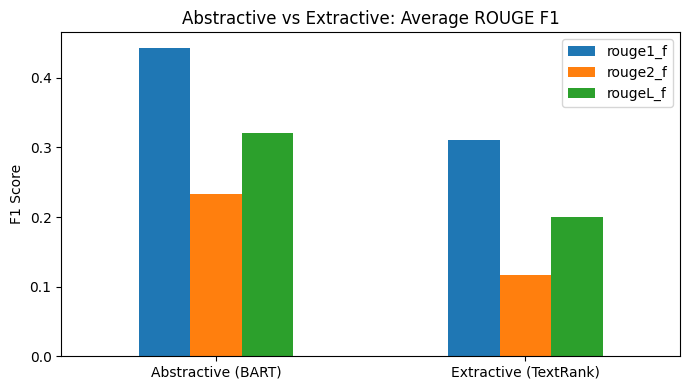

In [12]:
comparison_df.T.plot(kind='bar', figsize=(7, 4))
plt.title('Abstractive vs Extractive: Average ROUGE F1')
plt.ylabel('F1 Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Bonus: Fine-tune a Summarization Model

In [13]:
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

FT_MODEL_NAME = 't5-small'
FT_TRAIN_SAMPLES = 30
FT_EVAL_SAMPLES = 10
MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 128

ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)
ft_model = AutoModelForSeq2SeqLM.from_pretrained(FT_MODEL_NAME)

train_df = df.iloc[:FT_TRAIN_SAMPLES]
eval_df = df.iloc[FT_TRAIN_SAMPLES:FT_TRAIN_SAMPLES + FT_EVAL_SAMPLES]

def preprocess_function(examples):
    inputs = ['summarize: ' + a for a in examples['article']]
    model_inputs = ft_tokenizer(inputs, max_length=MAX_INPUT_LEN, truncation=True)
    labels = ft_tokenizer(text_target=examples['highlights'], max_length=MAX_TARGET_LEN, truncation=True)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_ds = Dataset.from_pandas(train_df[['article', 'highlights']])
eval_ds = Dataset.from_pandas(eval_df[['article', 'highlights']])
train_ds = train_ds.map(preprocess_function, batched=True, remove_columns=train_ds.column_names)
eval_ds = eval_ds.map(preprocess_function, batched=True, remove_columns=eval_ds.column_names)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [14]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.where(predictions != -100, predictions, ft_tokenizer.pad_token_id)
    decoded_preds = ft_tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, ft_tokenizer.pad_token_id)
    decoded_labels = ft_tokenizer.batch_decode(labels, skip_special_tokens=True)

    r1, r2, rl = [], [], []
    for pred, ref in zip(decoded_preds, decoded_labels):
        s = scorer.score(ref, pred)
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return {'rouge1': float(np.mean(r1)), 'rouge2': float(np.mean(r2)), 'rougeL': float(np.mean(rl))}

data_collator = DataCollatorForSeq2Seq(ft_tokenizer, model=ft_model)

training_args = Seq2SeqTrainingArguments(
    output_dir='finetuned_model',
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=3e-5,
    num_train_epochs=1,
    predict_with_generate=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=5,
    report_to=[],
)

trainer = Seq2SeqTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
    processing_class=ft_tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,2.541043,1.775075,0.319434,0.188666,0.254677


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8, training_loss=2.4430158734321594, metrics={'train_runtime': 10.398, 'train_samples_per_second': 2.885, 'train_steps_per_second': 0.769, 'total_flos': 4060254044160.0, 'train_loss': 2.4430158734321594, 'epoch': 1.0})

In [15]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel
2.541043,1.775075,1,0.320247,0.188923,0.255025


{'eval_loss': 1.7750746011734009,
 'eval_rouge1': 0.32024659509285164,
 'eval_rouge2': 0.18892256387487466,
 'eval_rougeL': 0.2550252695477833}